In [53]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

1. Выполните необходимую предварительную обработку и преобразуйте данные в формат Prophet.

2. Разделите данные на обучающую и тестовую выборки, используя первые 90% и последние 10% временного ряда соответственно.

3. Постройте модель Prophet на основе данных с использованием линейного тренда и сделайте прогноз на период тестовых данных.

4. Сделайте прогноз с помощью модели, включающей национальные праздники.

5. Скорректируйте тренд, изменив параметры `changepoint_range` и `changepoint_prior_scale`. Для каждого параметра попробуйте как минимум два разных значения, отличных от значений по умолчанию.

6. Сделайте прогнозы с помощью модели с логистическим трендом.

7. Сравните производительность моделей, полученных на шагах 3-6, по показателям MSE и MAPE на тестовых данных.

In [18]:
sales = sm.datasets.get_rdataset("DutchSales", "AER").data
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    425 non-null    float64
 1   value   425 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 6.8 KB


### Предобработка

In [19]:
# Convert decimal year to pandas datetime
def convert_decimal_year_to_datetime(decimal_years):
    dates = [(pd.to_datetime(f'{int(year)}-01-01') + pd.to_timedelta((year - int(year)) * 365.25, unit='D')).date()
             for year in decimal_years]
    return dates

# # Convert to Prophet format
sales['time'] = convert_decimal_year_to_datetime(sales['time'])
sales.rename(columns={'time': 'ds', 'value': 'y'}, inplace=True)

# Convert the column ds to datetime
sales['ds'] = pd.to_datetime(sales['ds'])
print("\nConverted:\n------------------\n", sales.head())


Converted:
------------------
           ds   y
0 1960-05-01  14
1 1960-06-01  13
2 1960-07-01  15
3 1960-08-01  13
4 1960-08-31  13


In [21]:
# Resample to monthly frequency based on the ds column
sales = sales.resample('MS', on='ds').mean().reset_index()

# Replace NaN with the mean of the previous and next value
sales['y'] = sales['y'].interpolate()
print("\nResampled:\n------------------\n", sales.head())


Resampled:
------------------
           ds     y
0 1960-05-01  14.0
1 1960-06-01  13.0
2 1960-07-01  15.0
3 1960-08-01  13.0
4 1960-09-01  15.0


### Деление на train и test 

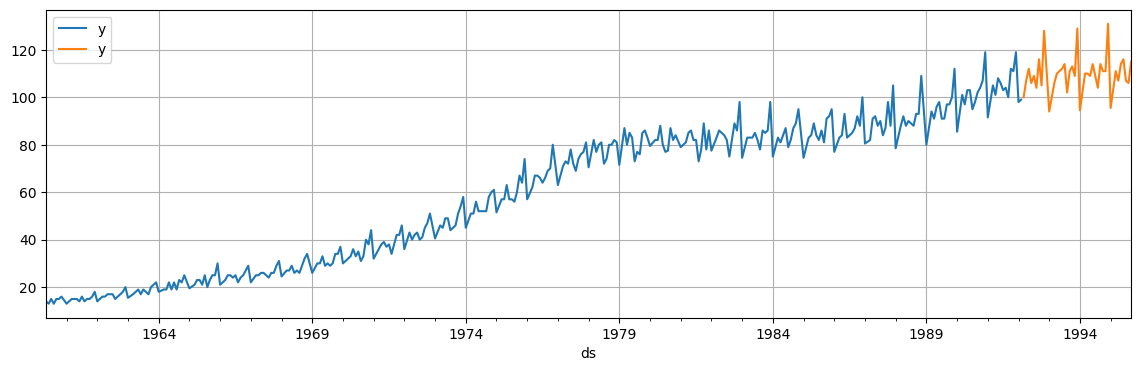

In [22]:
# Note that we need to make a copy here since we will modify the data
train = sales.iloc[:int(sales.shape[0] * 0.9)].copy()
test = sales.iloc[int(sales.shape[0] * 0.9):].copy()

fig, ax = plt.subplots(figsize=(10, 4))
train.plot(x='ds', y='y', figsize=(14, 4), grid=True, ax=ax)
test.plot(x='ds', y='y', figsize=(14, 4), grid=True, ax=ax)
plt.show()

### Модель Prophet со стандартными параметрами

In [25]:
model = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90)
model.fit(train)


17:59:58 - cmdstanpy - INFO - Chain [1] start processing
17:59:59 - cmdstanpy - INFO - Chain [1] done processing


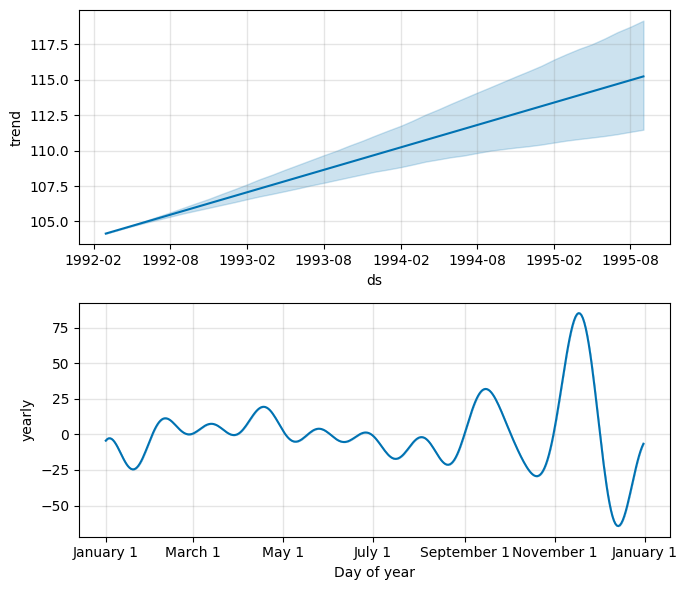

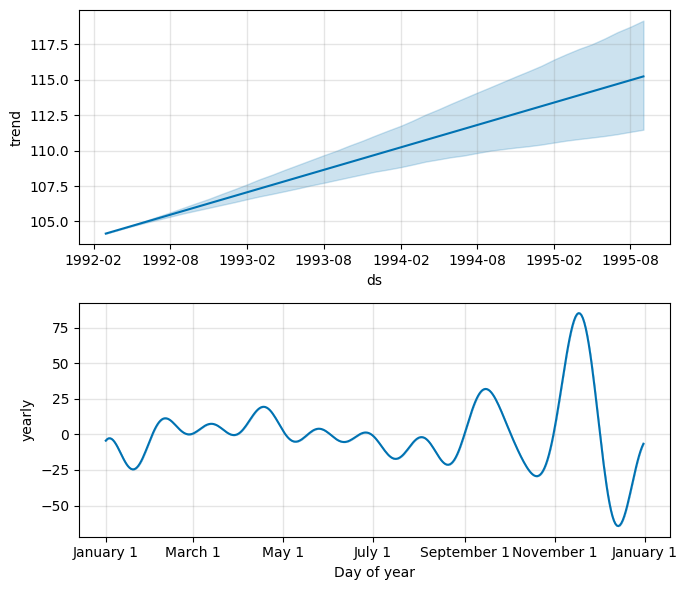

In [64]:
forecast = model.predict(test)
model.plot_components(forecast, figsize=(7, 6))

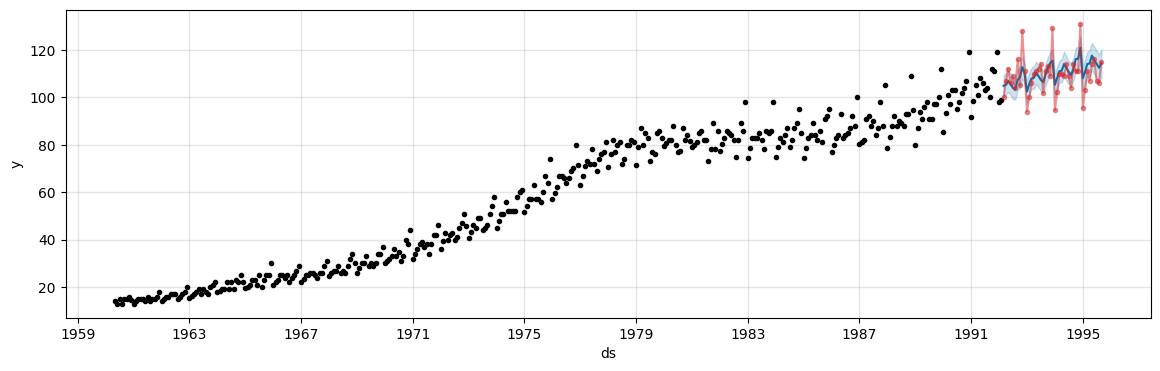

In [55]:
future = pd.DataFrame({'ds': pd.concat([train['ds'], test['ds']])}) # Init df for predictions

fig, ax = plt.subplots(figsize=(14, 4))
fig = model.plot(forecast, ax=ax)
ax.plot(test['ds'], test['y'], 'tab:red', marker='o', markersize=3, alpha=0.5);

In [147]:
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 84.28941785130768, mape: 0.06700713821736608


### Модель Prophet с национальными праздниками

In [69]:
model_holidays = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90)
model_holidays.add_country_holidays(country_name='NL')
model_holidays.fit(train)

18:42:04 - cmdstanpy - INFO - Chain [1] start processing
18:42:04 - cmdstanpy - INFO - Chain [1] done processing


In [70]:
model_holidays.predict(test)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Ascension Day,Ascension Day_lower,Ascension Day_upper,Christmas Day,...,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1992-03-01,104.605906,100.503689,109.361259,104.605906,104.605906,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.393665,0.393665,0.393665,0.0,0.0,0.0,104.999571
1,1992-04-01,104.875722,101.022019,109.795203,104.872639,104.882614,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.467870,0.467870,0.467870,0.0,0.0,0.0,105.343592
2,1992-05-01,105.136834,102.640116,111.559392,105.110038,105.166375,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,1.910013,1.910013,1.910013,0.0,0.0,0.0,107.046847
3,1992-06-01,105.406650,101.171278,110.175280,105.349360,105.464954,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.252681,0.252681,0.252681,0.0,0.0,0.0,105.659331
4,1992-07-01,105.667763,99.495811,108.471247,105.573352,105.767559,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,-1.630047,-1.630047,-1.630047,0.0,0.0,0.0,104.037716
5,1992-08-01,105.937579,98.677127,107.700329,105.795196,106.084704,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,-2.531159,-2.531159,-2.531159,0.0,0.0,0.0,103.406420
6,1992-09-01,106.207395,102.716476,111.857196,106.007136,106.398222,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,1.178334,1.178334,1.178334,0.0,0.0,0.0,107.385730
7,1992-10-01,106.468508,104.086042,113.045557,106.217237,106.706867,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,2.197486,2.197486,2.197486,0.0,0.0,0.0,108.665993
8,1992-11-01,106.738324,108.532322,117.146217,106.413735,107.025860,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,6.162755,6.162755,6.162755,0.0,0.0,0.0,112.901079
9,1992-12-01,106.999436,105.651058,114.458103,106.610035,107.350782,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,3.150904,3.150904,3.150904,0.0,0.0,0.0,110.150340


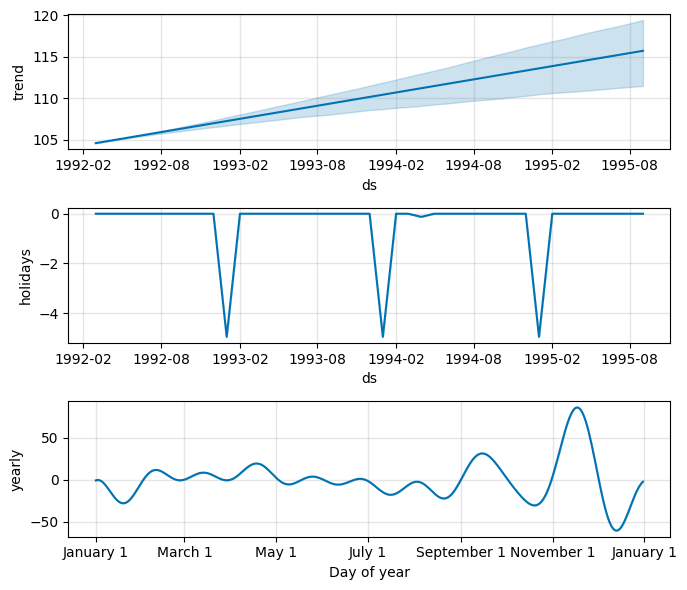

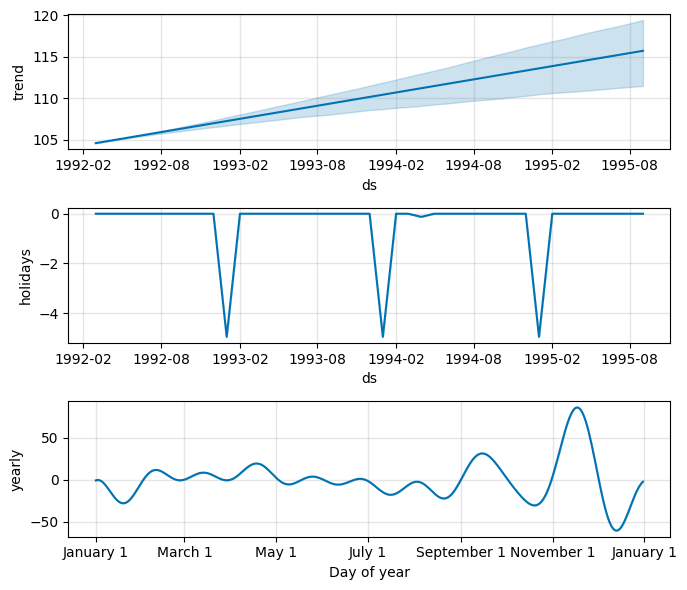

In [75]:
forecast = model_holidays.predict(test)
model_holidays.plot_components(forecast, figsize=(7, 6))

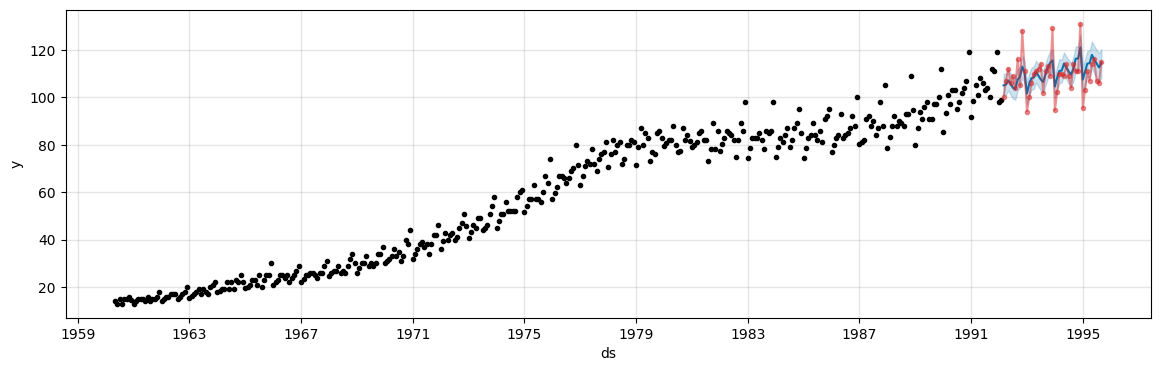

In [76]:
future = future = pd.DataFrame({'ds': pd.concat([train['ds'], test['ds']])}) # Init df for predictions

fig, ax = plt.subplots(figsize=(14, 4))
fig = model_holidays.plot(forecast, ax=ax)
ax.plot(test['ds'], test['y'], 'tab:red', marker='o', markersize=3, alpha=0.5);

In [77]:
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 35.383561696551695, mape: 0.043063864835420795


### Корректировка тренда 

####  changepoint_range

Изменим changepoint_range с 0.8 на 0.6

In [78]:
model_changepoint_range = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90, changepoint_range=0.6)
model_changepoint_range.fit(train)

18:43:32 - cmdstanpy - INFO - Chain [1] start processing
18:43:32 - cmdstanpy - INFO - Chain [1] done processing


In [79]:
forecast = model_changepoint_range.predict(test)

In [80]:
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 67.01239459596836, mape: 0.056940176900486784


Изменим changepoint_range с 0.8 на 0.9

In [81]:
model_changepoint_range = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90, changepoint_range=0.9)
model_changepoint_range.fit(train)

18:44:11 - cmdstanpy - INFO - Chain [1] start processing
18:44:11 - cmdstanpy - INFO - Chain [1] done processing


In [83]:
forecast = model_changepoint_range.predict(test)
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 63.830785944768564, mape: 0.06327413343506096


#### changepoint_prior_scale

Изменим changepoint_prior_scale с 0.05 на 0.01

In [85]:
model_changepoint_prior_scale = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90, changepoint_prior_scale=0.01)
model_changepoint_prior_scale.fit(train)

18:45:57 - cmdstanpy - INFO - Chain [1] start processing
18:45:57 - cmdstanpy - INFO - Chain [1] done processing


In [87]:
forecast = model_changepoint_prior_scale.predict(test)
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 52.04570180186522, mape: 0.04752693666733115


Изменим changepoint_prior_scale с 0.05 на 0.1

In [88]:
model_changepoint_prior_scale = Prophet(growth='linear', seasonality_mode='additive', interval_width=0.90, changepoint_prior_scale=0.1)
model_changepoint_prior_scale.fit(train)

18:46:35 - cmdstanpy - INFO - Chain [1] start processing
18:46:35 - cmdstanpy - INFO - Chain [1] done processing


In [89]:
forecast = model_changepoint_prior_scale.predict(test)
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 38.5391234086416, mape: 0.04491517935214229


### Модель Prophet c логистическим трендом

In [126]:
train['cap'] = 120

In [127]:
model_logistic = Prophet(growth='logistic', seasonality_mode='additive', interval_width=0.90)
model_logistic.fit(train)

19:32:07 - cmdstanpy - INFO - Chain [1] start processing
19:32:07 - cmdstanpy - INFO - Chain [1] done processing


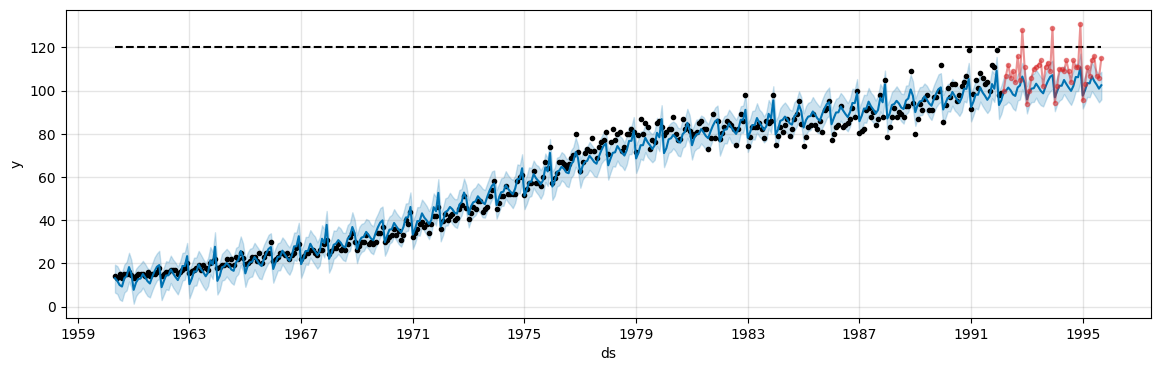

In [145]:
future = future = pd.DataFrame({'ds': pd.concat([train['ds'], test['ds']])}) # Init df for predictions
future['cap'] = 120                                     # Set the cap
fcst = model_logistic.predict(future)                                          # Compute forecasts
fig, ax = plt.subplots(figsize=(14, 4))
fig = model_logistic.plot(fcst, ax=ax)
ax.plot(test['ds'], test['y'], 'tab:red', marker='o', markersize=3, alpha=0.5)

In [146]:
test['cap'] = 120
forecast = model_logistic.predict(test)
mse = mean_squared_error(test['y'], forecast['yhat'])
mape = mean_absolute_percentage_error(test['y'], forecast['yhat'])
print(f'mse: {mse}, mape: {mape}')

mse: 84.28941785130768, mape: 0.06700713821736608
